# Creación BD S&P500

La idea es que del dataset con los precios, se tome el último día y se resten 1000 días, después se compare con el otro dataset de tickers para evaluar el sesgo de supervivencia. Los enlaces a dichos datasets se encuentran a continuación:

Dataset con la información de precios: https://www.kaggle.com/datasets/camnugent/sandp500?resource=download

Dataset con la información de tickers: https://github.com/fja05680/sp500

In [26]:
import pandas as pd
import os
import numpy as np
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt


In [27]:
# ---------------------------------------------------------
# BLOQUE 1: Configuración de Rutas y Carga Inicial
# ---------------------------------------------------------
folder_path = r'../../../data/processed'
path_main = os.path.join(folder_path, 'dataset_with_returns.csv')
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')

print("Cargando dataset principal...")
df = pd.read_csv(path_main)
df['date'] = pd.to_datetime(df['date'])

# Aseguramos el orden cronológico para que el recorte de registros sea correcto
df = df.sort_values(['Name', 'date'])

df.head()

Cargando dataset principal...


,date,open,high,low,close,volume,Name,adjusted_price,return_1d
0,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,28.576422,-0.010648
1,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,28.589230,0.000448
2,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525,0.002914
3,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612,-0.003799
4,2013-02-15,43.48,44.24,42.21,42.25,14657315,A,27.070713,-0.052266


In [28]:
df['date'] = pd.to_datetime(df['date'])

print("Fecha inicial:", df['date'].min())
print("Fecha final:", df['date'].max())

Fecha inicial: 2013-02-11 00:00:00
Fecha final: 2018-02-07 00:00:00


### Checking if there are dates gaps

In [29]:
def detect_real_gaps(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["Name", "date"])

    nyse = mcal.get_calendar("NYSE")

    gaps = []

    for name, group in df.groupby("Name"):
        group = group.sort_values("date").reset_index(drop=True)

        for i in range(1, len(group)):
            prev_date = group.loc[i-1, "date"]
            curr_date = group.loc[i, "date"]

            valid_days = nyse.valid_days(start_date=prev_date, end_date=curr_date)

            # deberían ser 2: prev y next
            if len(valid_days) > 2:
                gaps.append({
                    "Name": name,
                    "prev_date": prev_date,
                    "date": curr_date,
                    "missing_days": valid_days[1:-1]
                })

    return pd.DataFrame(gaps)
    
detect_real_gaps(df).shape

(17, 4)

### Avoiding survivor bias

To eliminate survivor bias, we first obtain all month-end constituent lists 
for the S&P 500 from January 2013 to December 2018. We consolidate these lists 
into a single binary matrix, indicating whether each stock is an index 
constituent in the subsequent month. In this way, we are able to approximately 
reproduce the S&P 500 composition at any point in time within this period. 
In a second step, for all stocks that have been constituents of the index at 
any time during this interval, we download daily total return indices covering 
the same time frame.

In [30]:
folder_path = r'../../../data/raw'
path_components = os.path.join(folder_path, 'S&P 500 Historical Components & Changes(01-17-2026).csv')
df_hist_comp = pd.read_csv(path_components)
df_hist_comp['date'] = pd.to_datetime(df_hist_comp['date'])

print(df_hist_comp.head())
print("...")
print(df_hist_comp.tail())

        date                                            tickers
0 1996-01-02  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
1 1996-01-03  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
2 1996-01-04  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
3 1996-01-10  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
4 1996-01-11  AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...
...
           date                                            tickers
2700 2025-11-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2701 2025-11-28  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2702 2025-12-11  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2703 2025-12-22  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...
2704 2026-01-14  A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...


In [31]:
df_hist_comp.dtypes

date       datetime64[us]
tickers               str
dtype: object

In [32]:
df.head()
first_date = df.iloc[0]['date']
print(first_date)

last_date = df.iloc[-1]['date']
print(last_date)

2013-02-11 00:00:00
2018-02-07 00:00:00


Creating pandas tables to see which companies were on S&P 500 at the end of the month

In [33]:
# Filtrar por fechas
df_hist_comp = df_hist_comp[(df_hist_comp['date'] >= first_date) & (df_hist_comp['date'] <= last_date)].copy()

# Extraer año y mes
df_hist_comp['year'] = df_hist_comp['date'].dt.year
df_hist_comp['month'] = df_hist_comp['date'].dt.month

# Tomar último día de cada mes
df_month_end = df_hist_comp.groupby(['year', 'month']).tail(1)

# Eliminar la columna 'date'
df_month_end = df_month_end.drop(columns=['date'])

# Reordenar columnas para que year y month queden primero
cols = ['year', 'month'] + [c for c in df_month_end.columns if c not in ['year', 'month']]
df_month_end = df_month_end[cols]

df_month_end = df_month_end.reset_index(drop=True)

# Revisar resultado
print(df_month_end.head())
print("...")
print(df_month_end.tail())

   year  month                                            tickers
0  2013      2  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
1  2013      3  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
2  2013      4  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
3  2013      5  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
4  2013      6  A,AABA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,ADP,...
...
    year  month                                            tickers
56  2017     10  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
57  2017     11  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
58  2017     12  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
59  2018      1  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...
60  2018      2  A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,A...


Creating Binary matrix

In [34]:
all_tickers = set()

for tickers_str in df_hist_comp['tickers']:
    for t in tickers_str.split(','):
        all_tickers.add(t.strip())
all_tickers = sorted(all_tickers)

ticker_dict = {ticker: idx for idx, ticker in enumerate(all_tickers)}


n_months = len(df_month_end)
n_tickers = len(all_tickers)

# matriz de ceros
binary_matrix = np.zeros((n_months, n_tickers), dtype=int)

for i, row in df_month_end.iterrows():
    tickers_in_row = row['tickers'].split(',')  # separa los tickers
    for t in tickers_in_row:
        t = t.strip()  # quitar espacios
        if t in ticker_dict:  # seguridad
            j = ticker_dict[t]  # columna correspondiente
            binary_matrix[i, j] = 1


binary_df = pd.DataFrame(binary_matrix, columns=all_tickers)
binary_df.insert(0, 'year', df_month_end['year'])
binary_df.insert(1, 'month', df_month_end['month'])

print(binary_df.head())

   year  month  A  AABA  AAL  AAP  AAPL  ABBV  ABC  ABT  ...  XL  XLNX  XOM  \
0  2013      2  1     1    0    0     1     1    1    1  ...   1     1    1   
1  2013      3  1     1    0    0     1     1    1    1  ...   1     1    1   
2  2013      4  1     1    0    0     1     1    1    1  ...   1     1    1   
3  2013      5  1     1    0    0     1     1    1    1  ...   1     1    1   
4  2013      6  1     1    0    0     1     1    1    1  ...   1     1    1   

   XRAY  XRX  XYL  YUM  ZBH  ZION  ZTS  
0     1    1    1    1    1     1    0  
1     1    1    1    1    1     1    0  
2     1    1    1    1    1     1    0  
3     1    1    1    1    1     1    0  
4     1    1    1    1    1     1    1  

[5 rows x 619 columns]


# Normalize data

In [35]:
data = df.copy()

# fecha a datetime
data['date'] = pd.to_datetime(data['date'])

# ordenar
data = data.sort_values(['Name', 'date'])

# columnas OHLCV
features = ['open', 'high', 'low', 'close', 'volume']

# percentage change normalization
for col in features:
    data[col] = (
        data.groupby('Name')[col]
        .pct_change() * 100
    )

# eliminar NaNs creados por pct_change
data = data.dropna().reset_index(drop=True)

print(data.head())

        date      open      high       low     close      volume Name  \
0 2013-02-12 -0.796989 -0.509075  0.112486  0.044843  -18.579717    A   
1 2013-02-13  0.000000  0.645161  0.404494  0.291349  -13.539571    A   
2 2013-02-14 -0.200848 -1.016799 -0.716204 -0.379888   86.433472    A   
3 2013-02-15 -2.772809 -1.205895 -4.846709 -5.226559  283.073091    A   
4 2013-02-19 -2.920883 -2.531646  0.000000  1.798817  -71.917496    A   

   adjusted_price  return_1d  
0       28.589230   0.000448  
1       28.672525   0.002914  
2       28.563612  -0.003799  
3       27.070713  -0.052266  
4       27.557655   0.017988  


In [36]:
# eliminar columnas innecesarias
data = data.drop(columns=['adjusted_price', 'return_1d'])

# verificar
print(data.head())

        date      open      high       low     close      volume Name
0 2013-02-12 -0.796989 -0.509075  0.112486  0.044843  -18.579717    A
1 2013-02-13  0.000000  0.645161  0.404494  0.291349  -13.539571    A
2 2013-02-14 -0.200848 -1.016799 -0.716204 -0.379888   86.433472    A
3 2013-02-15 -2.772809 -1.205895 -4.846709 -5.226559  283.073091    A
4 2013-02-19 -2.920883 -2.531646  0.000000  1.798817  -71.917496    A


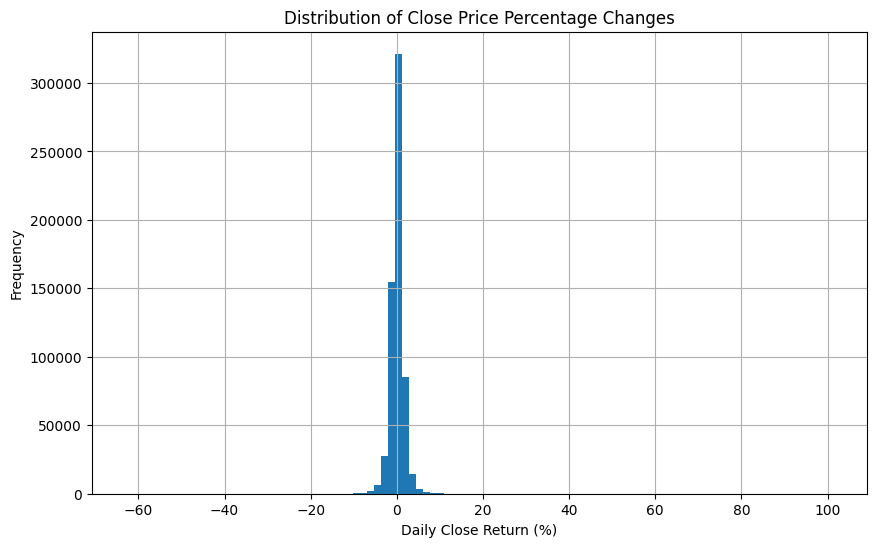

In [37]:
# tamaño figura
plt.figure(figsize=(10,6))

# histograma de returns del close
plt.hist(data['close'], bins=100)

# títulos
plt.title('Distribution of Close Price Percentage Changes')
plt.xlabel('Daily Close Return (%)')
plt.ylabel('Frequency')

# grid
plt.grid(True)

plt.show()

# Create sequences

## Cleaning data

### Filtrar tickers usando la matriz binaria

This function is made so it search the companies that were on S&P500 the last month of the 1000 blocks day

In [38]:
def get_tickers_for_period(binary_df, last_train_date):
    year = last_train_date.year
    month = last_train_date.month
    
    row = binary_df[
        (binary_df['year'] == year) &
        (binary_df['month'] == month)
    ]
    
    if row.empty:
        return []
    
    tickers_series = row.drop(columns=['year', 'month']).iloc[0]
    tickers = tickers_series[tickers_series == 1].index.tolist()
    
    return tickers

final_date = df['date'].max()
tickers_to_use = get_tickers_for_period(binary_df, final_date)
print(len(tickers_to_use))

data = data[
    data['Name'].isin(tickers_to_use)
].copy()

print(data.shape)
print(data['Name'].nunique())


506
(610470, 7)
499


In [39]:
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-12,-0.796989,-0.509075,0.112486,0.044843,-18.579717,A
1,2013-02-13,0.000000,0.645161,0.404494,0.291349,-13.539571,A
2,2013-02-14,-0.200848,-1.016799,-0.716204,-0.379888,86.433472,A
3,2013-02-15,-2.772809,-1.205895,-4.846709,-5.226559,283.073091,A
4,2013-02-19,-2.920883,-2.531646,0.000000,1.798817,-71.917496,A


In [40]:
ticker_counts = data.groupby('Name').size()

print("\nDistribución de cantidad de filas por ticker:")
print(ticker_counts.describe())

# mínimo recomendado
MIN_DAYS = 252

valid_tickers = ticker_counts[
    ticker_counts >= MIN_DAYS
].index

data = data[
    data['Name'].isin(valid_tickers)
].reset_index(drop=True)

print("\nTickers después de filtrar por mínimo de días:")
print(len(valid_tickers))


Distribución de cantidad de filas por ticker:
count     499.000000
mean     1223.386774
std       161.493136
min        42.000000
25%      1257.000000
50%      1257.000000
75%      1257.000000
max      1257.000000
dtype: float64

Tickers después de filtrar por mínimo de días:
494


### Revisar gaps temporales

In [41]:
print("\nRevisando gaps temporales...")

tickers_without_large_gaps = []

MAX_ALLOWED_GAP = 10

for ticker in data['Name'].unique():

    temp = data[data['Name'] == ticker].sort_values('date')

    gaps = temp['date'].diff().dt.days

    max_gap = gaps.max()

    if pd.isna(max_gap):
        continue

    if max_gap <= MAX_ALLOWED_GAP:
        tickers_without_large_gaps.append(ticker)

print("Tickers sin gaps grandes:",
      len(tickers_without_large_gaps))

data = data[
    data['Name'].isin(tickers_without_large_gaps)
].reset_index(drop=True)




Revisando gaps temporales...
Tickers sin gaps grandes: 491


### Delete extrem outliers

In [42]:
print("\nEstadísticas antes de tratar outliers:")
print(data[features].describe())

# features de precios
price_features = ['open', 'high', 'low', 'close']

# threshold razonable para returns %
PRICE_CLIP_THRESHOLD = 50

# clip de returns extremos en precios
for col in price_features:

    data[col] = data[col].clip(
        lower=-PRICE_CLIP_THRESHOLD,
        upper=PRICE_CLIP_THRESHOLD
    )

# volume suele explotar mucho más
# usar threshold más amplio
VOLUME_CLIP_THRESHOLD = 500

data['volume'] = data['volume'].clip(
    lower=-VOLUME_CLIP_THRESHOLD,
    upper=VOLUME_CLIP_THRESHOLD
)

print("\nEstadísticas después del clipping:")
print(data[features].describe())

print("\nShape después del clipping:")
print(data.shape)


Estadísticas antes de tratar outliers:
                open           high            low          close  \
count  606100.000000  606100.000000  606100.000000  606100.000000   
mean        0.054666       0.053349       0.054841       0.054569   
std         1.618789       1.466458       1.742578       1.609738   
min       -61.390046     -60.752571     -85.847202     -62.618262   
25%        -0.686429      -0.583447      -0.581962      -0.680478   
50%         0.072605       0.027967       0.097823       0.063573   
75%         0.815959       0.668236       0.749904       0.811908   
max        80.554076      58.633426     575.185185     100.951315   

              volume  
count  606100.000000  
mean       10.271443  
std       779.506337  
min       -95.066563  
25%       -21.961183  
50%        -1.183099  
75%        26.414862  
max    605079.000000  

Estadísticas después del clipping:
                open           high            low          close  \
count  606100.000000  6061

In [43]:
print(data.isna().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64


In [44]:
data = data.dropna().reset_index(drop=True)

In [45]:
print(data.isna().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64


## Create sequences

In [46]:
import numpy as np

features = ['open', 'high', 'low', 'close', 'volume']

# longitud de secuencia
SEQ_LEN = 20

X = []
y = []

# fechas target de cada secuencia
sequence_dates = []

# opcional: guardar ticker de cada sample
sequence_tickers = []

# Creación de secuencias
tickers_to_use = data['Name'].unique()

for ticker in tickers_to_use:

    # datos del ticker
    ticker_df = data[
        data['Name'] == ticker
    ].sort_values('date')

    # valores numpy
    values = ticker_df[features].values

    # fechas
    dates = ticker_df['date'].values

    # evitar tickers muy pequeños
    if len(values) <= SEQ_LEN:
        continue

    for i in range(len(values) - SEQ_LEN):

        # input sequence
        seq_x = values[i:i+SEQ_LEN]

        # target = close del siguiente día
        target_y = values[i+SEQ_LEN][3]

        # fecha correspondiente al target
        target_date = dates[i+SEQ_LEN]

        # guardar
        X.append(seq_x)
        y.append(target_y)

        sequence_dates.append(target_date)

        sequence_tickers.append(ticker)


X = np.array(X, dtype=np.float32)

y_regression = np.array(y, dtype=np.float32)

sequence_dates = np.array(sequence_dates)

sequence_tickers = np.array(sequence_tickers)

# INFO
print("X shape:", X.shape)
print("y shape:", y_regression.shape)

print("sequence_dates shape:", sequence_dates.shape)
print("sequence_tickers shape:", sequence_tickers.shape)

print("\nPrimera fecha:")
print(sequence_dates[0])

print("\nÚltima fecha:")
print(sequence_dates[-1])

X shape: (596280, 20, 5)
y shape: (596280,)
sequence_dates shape: (596280,)
sequence_tickers shape: (596280,)

Primera fecha:
2013-03-13T00:00:00.000000

Última fecha:
2018-02-07T00:00:00.000000


## Classification targets

In [47]:
targets_df = pd.DataFrame({

    'date': sequence_dates,
    'ticker': sequence_tickers,
    'return': y_regression

})

In [48]:
targets_df['cross_sectional_median'] = (

    targets_df
    .groupby('date')['return']
    .transform('median')

)

In [49]:
targets_df['class_target'] = (

    targets_df['return']
    >= targets_df['cross_sectional_median']

).astype(np.int8)

In [50]:
y_classification = targets_df['class_target'].values.astype(np.int8)

In [51]:
y_classification

array([1, 1, 0, ..., 0, 0, 1], dtype=int8)

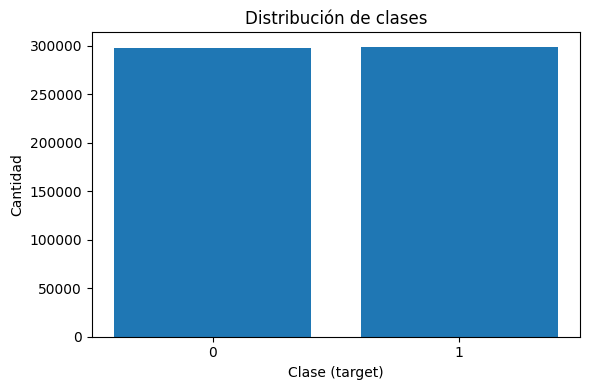

In [52]:
counts = pd.Series(y_classification).value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.xlabel("Clase (target)")
plt.ylabel("Cantidad")
plt.title("Distribución de clases")

plt.tight_layout()
plt.show()

# Save data

In [53]:

np.savez_compressed(

    'financial_dataset.npz',

    # inputs
    X=X,

    # targets
    y_regression=y_regression,
    y_classification=y_classification,

    # metadata
    sequence_dates=sequence_dates,
    sequence_tickers=sequence_tickers
)

print("Dataset guardado correctamente")

Dataset guardado correctamente
